In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df=pd.read_csv("customer_behavior.csv")
df

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN


In [3]:
df.shape

(5000, 7)

In [4]:
df.columns.tolist()

['CustomerID',
 'Gender',
 'Region',
 'PurchaseAmount',
 'ProductCategory',
 'Churn',
 'CampaignGroup']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [6]:
df.isnull().sum()

CustomerID           0
Gender              97
Region             175
PurchaseAmount     150
ProductCategory    526
Churn              265
CampaignGroup      185
dtype: int64

In [7]:
df['PurchaseAmount']

0        256.07
1           NaN
2       1194.41
3        413.06
4       1556.32
         ...   
4995    1497.00
4996     978.87
4997     906.93
4998     375.67
4999    1392.74
Name: PurchaseAmount, Length: 5000, dtype: float64

In [8]:
# 1. What is the average, median, and mode of PurchaseAmount?

purchase = df["PurchaseAmount"].dropna()
average = purchase.mean()
median = purchase.median()
mode = purchase.mode()[0]

print("Average PurchaseAmount:", average)
print("Median PurchaseAmount:", median)
print("Mode PurchaseAmount:", mode)

Average PurchaseAmount: 1003.9506701030928
Median PurchaseAmount: 998.0799999999999
Mode PurchaseAmount: 0.0


In [24]:
# 2. Are there any outliers in the PurchaseAmount data?
Q1 = purchase.quantile(0.25)
Q3 = purchase.quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = purchase[(purchase < lower_bound) | (purchase > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_bound)
print("Upper Limit:", upper_bound)
print("Number of Outliers:", len(outliers))
print("Outliers:\n",outliers.tolist())



Q1: 673.6424999999999
Q3: 1327.0775
IQR: 653.4350000000002
Lower Limit: -306.51000000000033
Upper Limit: 2307.2300000000005
Number of Outliers: 15
Outliers:
 [2318.33, 2496.41, 2688.69, 2349.16, 2578.89, 2384.19, 2457.05, 2316.19, 2400.69, 2357.41, 2688.88, 2643.88, 2472.62, 2484.75, 2642.06]


In [10]:
#3. Is there any skewness or kurtosis in the PurchaseAmount distribution?
print("Skewness:",df['PurchaseAmount'].skew())
print("Kurtosis:",df['PurchaseAmount'].kurt())

Skewness: 0.10609189374631554
Kurtosis: -0.2615105545319705


In [11]:
#4. Is there a significant difference in spending between male and female customers?
male_spending=df[df['Gender']=='Male']['PurchaseAmount'].dropna()
female_spending=df[df['Gender']=='Female']['PurchaseAmount'].dropna()
print("Male average:",male_spending.mean())
print("Female average:",female_spending.mean())
from scipy.stats import ttest_ind
t_stat,p_value=ttest_ind(male_spending,female_spending,equal_var=False)

print("T-statistic:",t_stat)
print("P-value:",p_value)
if p_value < 0.05:
    print("There is a significant difference")
else:
    print("There is  no significant difference")

Male average: 1019.1766093880973
Female average: 987.8720464135021
T-statistic: 2.234798912073049
P-value: 0.025476849797238143
There is a significant difference


In [ ]:
#5.

In [12]:
df['ProductCategory']

0           Fashion
1       Electronics
2           Fashion
3           Grocery
4           Fashion
           ...     
4995    Electronics
4996        Fashion
4997        Fashion
4998        Fashion
4999        Grocery
Name: ProductCategory, Length: 5000, dtype: object

In [13]:
df['Churn']

0        No
1       Yes
2        No
3        No
4       Yes
       ... 
4995    Yes
4996    Yes
4997     No
4998     No
4999    Yes
Name: Churn, Length: 5000, dtype: object

In [14]:
contingency_table=pd.crosstab(df['ProductCategory'],df['Churn'])
print(contingency_table)

Churn             No  Yes
ProductCategory          
Electronics      785  541
Fashion          839  607
Grocery          855  604


In [15]:
#5. Is there a relationship between ProductCategory and customer churn?
contingency_table=pd.crosstab(df['ProductCategory'],df['Churn'])
from scipy.stats import chi2_contingency
chi2,p_value,dof,expected=chi2_contingency(contingency_table)
print("Chi-Square Statistic:",chi2)
print("P-value:",p_value)
print("Degrees of Freedom:",dof)
print("Expected Frequencies:\n",expected)
if p_value < 0.05:
    print("There is a significant relationship.")
else:
    print("There is no significant relationship.")

Chi-Square Statistic: 0.3960436652673918
P-value: 0.8203519424988512
Degrees of Freedom: 2
Expected Frequencies:
 [[776.9212952  549.0787048 ]
 [847.23091468 598.76908532]
 [854.84779012 604.15220988]]
There is no significant relationship.


In [ ]:
#6.

In [16]:
df['Region'].unique().tolist()

['South', 'West', 'North', 'East', nan]

In [17]:
#6. Does PurchaseAmount vary significantly across different regions?
from scipy.stats import f_oneway

south = df[df["Region"] == "South"]["PurchaseAmount"].dropna()
west = df[df["Region"] == "West"]["PurchaseAmount"].dropna()
north = df[df["Region"] == "North"]["PurchaseAmount"].dropna()
east = df[df["Region"] == "East"]["PurchaseAmount"].dropna()

print("South Average:", south.mean())
print("West Average:", west.mean())
print("North Average:", north.mean())
print("East Average:", east.mean())


f_stat, p_value = f_oneway(south, west,north,east,)

print("\nF-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Conclusion: There is a significant difference across regions.")
else:
    print("Conclusion: There is no significant difference across regions.")

South Average: 997.6038768718801
West Average: 995.24732735426
North Average: 1013.0179520137106
East Average: 1009.9460167364017

F-statistic: 0.389667863548067
P-value: 0.760452802731563
Conclusion: There is no significant difference across regions.


In [26]:
#7. Which email campaign (A or B) performed better in terms of average PurchaseAmount?
from scipy.stats import ttest_ind
A = df[df["CampaignGroup"] == "A"]["PurchaseAmount"].dropna()
B = df[df["CampaignGroup"] == "B"]["PurchaseAmount"].dropna()
print("Campaign A Average:", A.mean())
print("Campaign B Average:", B.mean())
#campaign_average=df.groupby("CampaignGroup")["PurchaseAmount"].mean()
#print(campaign_average)
t_stat, p_value = ttest_ind(A, B, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("There is a significant difference between Campaign A and B.")
else:
    print("There is no significant difference between Campaign A and B.")

Campaign A Average: 1011.9455872340425
Campaign B Average: 994.3399654874893
T-statistic: 1.2430861943551852
P-value: 0.21389858277292212
There is no significant difference between Campaign A and B.


In [19]:
#8. Can we assume PurchaseAmount follows a normal distribution?
from scipy.stats import normaltest
purchase = df["PurchaseAmount"].dropna()
stat, p_value = normaltest(purchase)
print("Test Statistic:", stat)
print("P-value:", p_value)
if p_value < 0.05:
    print("PurchaseAmount is not normally distributed.")
else:
    print("PurchaseAmount follows a normal distribution.")

Test Statistic: 27.251556517359987
P-value: 1.208925924000244e-06
PurchaseAmount is not normally distributed.


In [20]:
#9. What insights can we gain by applying the Central Limit Theorem?
import numpy as np
purchase = df["PurchaseAmount"].dropna()
sample_means = []
for i in range(1000):
    sample = np.random.choice(purchase, size=30, replace=True)
    sample_means.append(sample.mean())

print("Original Mean:", purchase.mean())
print("Mean of Sample Means:", np.mean(sample_means))
print("Standard Deviation of Sample Means:", np.std(sample_means))

Original Mean: 1003.9506701030928
Mean of Sample Means: 1004.1007683333333
Standard Deviation of Sample Means: 91.12449104909781


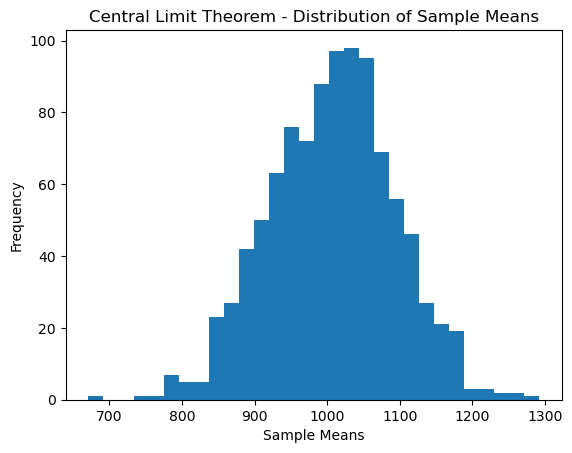

In [21]:
import numpy as np
import matplotlib.pyplot as plt

purchase = df["PurchaseAmount"].dropna()

sample_means = []

for i in range(1000):
    sample = np.random.choice(purchase, size=30, replace=True)
    sample_means.append(sample.mean())

plt.hist(sample_means, bins=30)
plt.xlabel("Sample Means")
plt.ylabel("Frequency")
plt.title("Central Limit Theorem - Distribution of Sample Means")
plt.show()

In [27]:
#10.What is the 95% confidence interval for the average PurchaseAmount?
from scipy.stats import t
import numpy as np

purchase = df["PurchaseAmount"].dropna()

n = len(purchase)
mean = purchase.mean()
std = purchase.std()

standard_error = std / np.sqrt(n)
critical_value = t.ppf(0.975, df=n-1)
margin_of_error = critical_value * standard_error

lower = mean - margin_of_error
upper = mean + margin_of_error

print("Mean:", mean)
print("Standard Error:",standard_error)
print("Margin of error:",margin_of_error)
print("95% Confidence Interval:")
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Mean: 1003.9506701030928
Standard Error: 6.922740985370979
Margin of error: 13.571710642171222
95% Confidence Interval:
Lower Bound: 990.3789594609216
Upper Bound: 1017.522380745264
